In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [6]:
df = pd.read_csv('/home/abinash/ML/campusx/datasets/placement.csv')

In [7]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


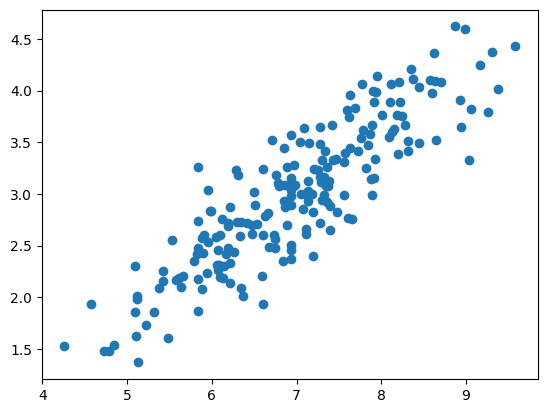

In [17]:
plt.scatter(df['cgpa'],df['package'])


In [9]:
x = df.iloc[:,0:1]
y = df.iloc[:,-1]

In [10]:
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [13]:
from sklearn.linear_model import LinearRegression

lr =LinearRegression()

lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
x_train

,cgpa
137,7.14
163,8.93
111,5.42
123,5.10
109,7.77
...,...
43,7.66
22,6.14
72,7.78
15,7.25


In [15]:
lr.predict(x_test.iloc[0].values.reshape(1,1))

/home/abinash/ML/venv/lib64/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([3.89111601])

Text(0, 0.5, 'Package(in lpa)')

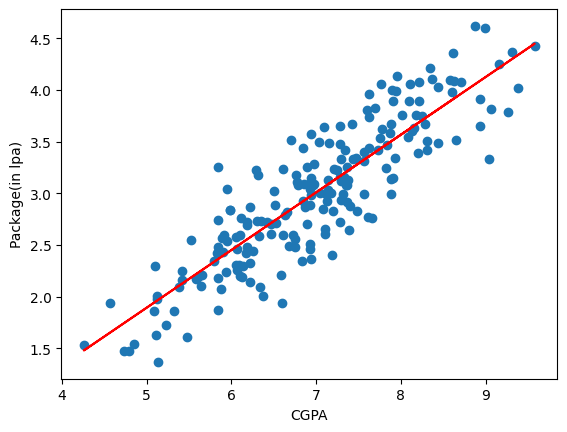

In [20]:
plt.scatter(df['cgpa'],df['package'])
plt.plot(x_train,lr.predict(x_train),color='red')
plt.xlabel('CGPA')
plt.ylabel('Package(in lpa)')

In [21]:
m=lr.coef_
b=lr.intercept_

In [22]:
print(m,b)

[0.55795197] -0.8961119222429144


In [23]:
m * 8.58 + b

array([3.89111601])

In [24]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [25]:
y_pred=lr.predict(x_test)

In [26]:
print("MAE",mean_absolute_error(y_test,y_pred))

MAE 0.2884710931878175


In [27]:
print("MAE",mean_squared_error(y_test,y_pred))

MAE 0.12129235313495527


In [29]:
print("MAE",np.sqrt(mean_squared_error(y_test,y_pred)))

MAE 0.34827051717731616


In [32]:
print("R2",r2_score(y_test,y_pred)) # here 78 % of prediction is done with the help of cgpa column

R2 0.780730147510384


In [31]:
r2=r2_score(y_test,y_pred)

In [33]:
num=(1-r2)*(40-1)
den=(40-1-1)
r2_adj=1-num/den

print(r2_adj)

0.7749598882343415
